In [47]:
import pandas as pd

In [48]:
matches = pd.read_csv("../data/processed/charting_m_matches_2021_clean.csv")
matches["Date"] = pd.to_datetime(matches["Date"], errors="coerce")

matches.head()

,match_id,Player 1,Player 2,Pl 1 hand,Pl 2 hand,Date,Tournament,Round,Surface,Best of,Final TB?,Year
0,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,Jesper De Jong,Michael Zheng,R,R,2026-05-21,Roland Garros,Q3,Clay,3,A,2026
1,20260517-M-Rome_Masters-F-Casper_Ruud-Jannik_S...,Casper Ruud,Jannik Sinner,R,R,2026-05-17,Rome Masters,F,Clay,3,1,2026
2,20260511-M-Rome_Masters-R16-Rafael_Jodar-Learn...,Rafael Jodar,Learner Tien,R,L,2026-05-11,Rome Masters,R16,Clay,3,1,2026
3,20260507-M-Rome_Masters-R128-Stefanos_Tsitsipa...,Stefanos Tsitsipas,Tomas Machac,R,R,2026-05-07,Rome Masters,R128,Clay,3,1,2026
4,20260503-M-Madrid_Masters-F-Jannik_Sinner-Alex...,Jannik Sinner,Alexander Zverev,R,R,2026-05-03,Madrid Masters,F,Clay,3,1,2026


In [49]:
points = pd.read_csv("../data/raw/charting-m-points-2020s.csv")

points.head()

/var/folders/0_/md9qp9653w30rpm1krm3232m0000gn/T/ipykernel_16691/3136240741.py:1: DtypeWarning: Columns (0: TbSet) have mixed types. Specify dtype option on import or set low_memory=False.
  points = pd.read_csv("../data/raw/charting-m-points-2020s.csv")


,match_id,Pt,Set1,Set2,Gm1,Gm2,Pts,Gm#,TbSet,Svr,1st,2nd,Notes,PtWinner
0,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,92,0,1,1,0.0,0-15,14,True,2,4b37y1r3n#,NaN,NaN,2
1,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,93,0,1,1,0.0,15-15,14,True,2,6n,5f18f1f1f3s3f-1l3*,NaN,1
2,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,94,0,1,1,0.0,15-30,14,True,2,4*,NaN,NaN,2
3,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,95,0,1,1,0.0,30-30,14,True,2,6b3n#,NaN,NaN,2
4,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,96,0,1,1,0.0,40-30,14,True,2,6f18f3d@,NaN,NaN,1


In [50]:
points.shape
points.columns
points.info()

<class 'pandas.DataFrame'>
RangeIndex: 547478 entries, 0 to 547477
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   match_id  547478 non-null  str    
 1   Pt        547478 non-null  int64  
 2   Set1      547478 non-null  int64  
 3   Set2      547478 non-null  int64  
 4   Gm1       547478 non-null  int64  
 5   Gm2       547477 non-null  float64
 6   Pts       547478 non-null  str    
 7   Gm#       547478 non-null  int64  
 8   TbSet     547477 non-null  object 
 9   Svr       547478 non-null  int64  
 10  1st       547478 non-null  str    
 11  2nd       201962 non-null  str    
 12  Notes     76345 non-null   str    
 13  PtWinner  547478 non-null  int64  
dtypes: float64(1), int64(7), object(1), str(5)
memory usage: 58.5+ MB


In [51]:
# Sort points by match_id and point number
points_sorted = points.sort_values(["match_id", "Pt"])

# Take the last point of each match
last_points = points_sorted.groupby("match_id").tail(1).copy()

# Keep only match_id and point winner
match_winners = last_points[["match_id", "PtWinner"]].copy()

match_winners.head()

,match_id,PtWinner
547477,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,1
547270,20200103-M-ATP_Cup-RR-Stefanos_Tsitsipas-Denis...,2
547103,20200103-M-ATP_Cup-RR-Steve_Darcis-Alexander_C...,1
546872,20200104-M-ATP_Cup-RR-Hubert_Hurkacz-Diego_Sch...,1
546687,20200104-M-ATP_Cup-RR-Nicolas_Jarry-Benoit_Paire,2


In [52]:
match_winners["PtWinner"].value_counts()

PtWinner
1    1714
2    1623
Name: count, dtype: int64

In [53]:
import pandas as pd

matches_clean = pd.read_csv("../data/processed/charting_m_matches_2021_clean.csv")
matches_clean["Date"] = pd.to_datetime(matches_clean["Date"], errors="coerce")

matches_clean.head()

,match_id,Player 1,Player 2,Pl 1 hand,Pl 2 hand,Date,Tournament,Round,Surface,Best of,Final TB?,Year
0,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,Jesper De Jong,Michael Zheng,R,R,2026-05-21,Roland Garros,Q3,Clay,3,A,2026
1,20260517-M-Rome_Masters-F-Casper_Ruud-Jannik_S...,Casper Ruud,Jannik Sinner,R,R,2026-05-17,Rome Masters,F,Clay,3,1,2026
2,20260511-M-Rome_Masters-R16-Rafael_Jodar-Learn...,Rafael Jodar,Learner Tien,R,L,2026-05-11,Rome Masters,R16,Clay,3,1,2026
3,20260507-M-Rome_Masters-R128-Stefanos_Tsitsipa...,Stefanos Tsitsipas,Tomas Machac,R,R,2026-05-07,Rome Masters,R128,Clay,3,1,2026
4,20260503-M-Madrid_Masters-F-Jannik_Sinner-Alex...,Jannik Sinner,Alexander Zverev,R,R,2026-05-03,Madrid Masters,F,Clay,3,1,2026


In [54]:
model_df = matches_clean.merge(match_winners, on="match_id", how="inner")

model_df.shape

(3167, 13)

In [55]:
model_df.head()

,match_id,Player 1,Player 2,Pl 1 hand,Pl 2 hand,Date,Tournament,Round,Surface,Best of,Final TB?,Year,PtWinner
0,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,Jesper De Jong,Michael Zheng,R,R,2026-05-21,Roland Garros,Q3,Clay,3,A,2026,2
1,20260517-M-Rome_Masters-F-Casper_Ruud-Jannik_S...,Casper Ruud,Jannik Sinner,R,R,2026-05-17,Rome Masters,F,Clay,3,1,2026,2
2,20260511-M-Rome_Masters-R16-Rafael_Jodar-Learn...,Rafael Jodar,Learner Tien,R,L,2026-05-11,Rome Masters,R16,Clay,3,1,2026,1
3,20260507-M-Rome_Masters-R128-Stefanos_Tsitsipa...,Stefanos Tsitsipas,Tomas Machac,R,R,2026-05-07,Rome Masters,R128,Clay,3,1,2026,2
4,20260503-M-Madrid_Masters-F-Jannik_Sinner-Alex...,Jannik Sinner,Alexander Zverev,R,R,2026-05-03,Madrid Masters,F,Clay,3,1,2026,1


In [56]:
model_df["target"] = model_df["PtWinner"].apply(lambda x: 1 if x == 1 else 0)

In [57]:
model_df["target"].value_counts()

target
1    1633
0    1534
Name: count, dtype: int64

In [58]:
model_df["Winner"] = model_df.apply(
    lambda row: row["Player 1"] if row["target"] == 1 else row["Player 2"],
    axis=1
)

model_df[["Player 1", "Player 2", "PtWinner", "target", "Winner"]].head(10)

,Player 1,Player 2,PtWinner,target,Winner
0,Jesper De Jong,Michael Zheng,2,0,Michael Zheng
1,Casper Ruud,Jannik Sinner,2,0,Jannik Sinner
2,Rafael Jodar,Learner Tien,1,1,Rafael Jodar
3,Stefanos Tsitsipas,Tomas Machac,2,0,Tomas Machac
4,Jannik Sinner,Alexander Zverev,1,1,Jannik Sinner
5,Arthur Fils,Jannik Sinner,2,0,Jannik Sinner
6,Alexander Zverev,Flavio Cobolli,1,1,Alexander Zverev
7,Rafael Jodar,Jannik Sinner,2,0,Jannik Sinner
8,Arthur Fils,Jiri Lehecka,1,1,Arthur Fils
9,Casper Ruud,Stefanos Tsitsipas,1,1,Casper Ruud


In [59]:
model_df.to_csv("../data/processed/labeled_matches_2021.csv", index=False)

In [60]:
features = [
    "Pl 1 hand",
    "Pl 2 hand",
    "Round",
    "Surface",
    "Best of",
    "Final TB?",
    "Year"
]

model_data = model_df[features + ["target"]].copy()

model_data.head()

,Pl 1 hand,Pl 2 hand,Round,Surface,Best of,Final TB?,Year,target
0,R,R,Q3,Clay,3,A,2026,0
1,R,R,F,Clay,3,1,2026,0
2,R,L,R16,Clay,3,1,2026,1
3,R,R,R128,Clay,3,1,2026,0
4,R,R,F,Clay,3,1,2026,1


In [61]:
model_data.shape

(3167, 8)

In [62]:
model_data.isnull().sum()

Pl 1 hand    0
Pl 2 hand    0
Round        0
Surface      0
Best of      0
Final TB?    0
Year         0
target       0
dtype: int64

In [63]:
model_data.to_csv("../data/processed/model_dataset_2021.csv", index=False)

In [64]:
model_df.head()

,match_id,Player 1,Player 2,Pl 1 hand,Pl 2 hand,Date,Tournament,Round,Surface,Best of,Final TB?,Year,PtWinner,target,Winner
0,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,Jesper De Jong,Michael Zheng,R,R,2026-05-21,Roland Garros,Q3,Clay,3,A,2026,2,0,Michael Zheng
1,20260517-M-Rome_Masters-F-Casper_Ruud-Jannik_S...,Casper Ruud,Jannik Sinner,R,R,2026-05-17,Rome Masters,F,Clay,3,1,2026,2,0,Jannik Sinner
2,20260511-M-Rome_Masters-R16-Rafael_Jodar-Learn...,Rafael Jodar,Learner Tien,R,L,2026-05-11,Rome Masters,R16,Clay,3,1,2026,1,1,Rafael Jodar
3,20260507-M-Rome_Masters-R128-Stefanos_Tsitsipa...,Stefanos Tsitsipas,Tomas Machac,R,R,2026-05-07,Rome Masters,R128,Clay,3,1,2026,2,0,Tomas Machac
4,20260503-M-Madrid_Masters-F-Jannik_Sinner-Alex...,Jannik Sinner,Alexander Zverev,R,R,2026-05-03,Madrid Masters,F,Clay,3,1,2026,1,1,Jannik Sinner


In [65]:
print(model_df.columns.tolist())

['match_id', 'Player 1', 'Player 2', 'Pl 1 hand', 'Pl 2 hand', 'Date', 'Tournament', 'Round', 'Surface', 'Best of', 'Final TB?', 'Year', 'PtWinner', 'target', 'Winner']


In [66]:
model_df = model_df.sort_values("Date").reset_index(drop=True)

In [67]:
from collections import defaultdict
import pandas as pd

player_matches = defaultdict(int)
player_wins = defaultdict(int)

player_surface_matches = defaultdict(int)
player_surface_wins = defaultdict(int)

features_list = []

for _, row in model_df.iterrows():
    p1 = row["Player 1"]
    p2 = row["Player 2"]
    surface = row["Surface"]
    winner = row["Winner"]

    p1_matches = player_matches[p1]
    p2_matches = player_matches[p2]

    p1_wins = player_wins[p1]
    p2_wins = player_wins[p2]

    p1_win_rate = p1_wins / p1_matches if p1_matches > 0 else 0.5
    p2_win_rate = p2_wins / p2_matches if p2_matches > 0 else 0.5

    p1_surface_key = (p1, surface)
    p2_surface_key = (p2, surface)

    p1_surface_matches = player_surface_matches[p1_surface_key]
    p2_surface_matches = player_surface_matches[p2_surface_key]

    p1_surface_wins = player_surface_wins[p1_surface_key]
    p2_surface_wins = player_surface_wins[p2_surface_key]

    p1_surface_win_rate = (
        p1_surface_wins / p1_surface_matches if p1_surface_matches > 0 else 0.5
    )

    p2_surface_win_rate = (
        p2_surface_wins / p2_surface_matches if p2_surface_matches > 0 else 0.5
    )

    features_list.append({
        "p1_previous_matches": p1_matches,
        "p2_previous_matches": p2_matches,
        "experience_diff": p1_matches - p2_matches,

        "p1_previous_win_rate": p1_win_rate,
        "p2_previous_win_rate": p2_win_rate,
        "win_rate_diff": p1_win_rate - p2_win_rate,

        "p1_surface_matches": p1_surface_matches,
        "p2_surface_matches": p2_surface_matches,
        "surface_experience_diff": p1_surface_matches - p2_surface_matches,

        "p1_surface_win_rate": p1_surface_win_rate,
        "p2_surface_win_rate": p2_surface_win_rate,
        "surface_win_rate_diff": p1_surface_win_rate - p2_surface_win_rate
    })

    # Update records AFTER feature creation to avoid data leakage
    player_matches[p1] += 1
    player_matches[p2] += 1

    if winner == p1:
        player_wins[p1] += 1
    else:
        player_wins[p2] += 1

    player_surface_matches[p1_surface_key] += 1
    player_surface_matches[p2_surface_key] += 1

    if winner == p1:
        player_surface_wins[p1_surface_key] += 1
    else:
        player_surface_wins[p2_surface_key] += 1

historical_features = pd.DataFrame(features_list)

historical_features.head()

,p1_previous_matches,p2_previous_matches,experience_diff,p1_previous_win_rate,p2_previous_win_rate,win_rate_diff,p1_surface_matches,p2_surface_matches,surface_experience_diff,p1_surface_win_rate,p2_surface_win_rate,surface_win_rate_diff
0,0,0,0,0.5,0.5,0.0,0,0,0,0.5,0.5,0.0
1,1,0,1,1.0,0.5,0.5,1,0,1,1.0,0.5,0.5
2,0,0,0,0.5,0.5,0.0,0,0,0,0.5,0.5,0.0
3,0,0,0,0.5,0.5,0.0,0,0,0,0.5,0.5,0.0
4,0,0,0,0.5,0.5,0.0,0,0,0,0.5,0.5,0.0


In [68]:
model_df_features = pd.concat(
    [model_df.reset_index(drop=True), historical_features],
    axis=1
)

model_df_features.head()

,match_id,Player 1,Player 2,Pl 1 hand,Pl 2 hand,Date,Tournament,Round,Surface,Best of,...,experience_diff,p1_previous_win_rate,p2_previous_win_rate,win_rate_diff,p1_surface_matches,p2_surface_matches,surface_experience_diff,p1_surface_win_rate,p2_surface_win_rate,surface_win_rate_diff
0,20210110-M-Delray_Beach-R16-Daniel_Elahi_Galan...,Daniel Elahi Galan,Hubert Hurkacz,R,R,2021-01-10,Delray Beach,R16,Hard,3,...,0,0.5,0.5,0.0,0,0,0,0.5,0.5,0.0
1,20210111-M-Delray_Beach-QF-Hubert_Hurkacz-Robe...,Hubert Hurkacz,Roberto Quiroz,R,L,2021-01-11,Delray Beach,QF,Hard,3,...,1,1.0,0.5,0.5,1,0,1,1.0,0.5,0.5
2,20210113-M-Antalya-F-Alex_De_Minaur-Alexander_...,Alex De Minaur,Alexander Bublik,R,R,2021-01-13,Antalya,F,Hard,3,...,0,0.5,0.5,0.0,0,0,0,0.5,0.5,0.0
3,20210202-M-Great_Ocean_Road_Open-R64-Tristan_S...,Tristan Schoolkate,Botic Van De Zandschulp,R,R,2021-02-02,Great Ocean Road Open,R64,Hard,3,...,0,0.5,0.5,0.0,0,0,0,0.5,0.5,0.0
4,20210202-M-ATP_Cup-RR-Andrey_Rublev-Guido_Pella,Andrey Rublev,Guido Pella,R,L,2021-02-02,ATP Cup,RR,Hard,3,...,0,0.5,0.5,0.0,0,0,0,0.5,0.5,0.0


In [69]:
model_df["target"] = model_df["PtWinner"].apply(
    lambda x: 1 if x == 1 else 0
)

In [70]:
model_df["Winner"] = model_df.apply(
    lambda row: (
        row["Player 1"]
        if row["target"] == 1
        else row["Player 2"]
    ),
    axis=1
)

In [71]:
features = [
    "Pl 1 hand",
    "Pl 2 hand",
    "Round",
    "Surface",
    "Best of",
    "Final TB?",
    "Year",

    "p1_previous_matches",
    "p2_previous_matches",
    "experience_diff",

    "p1_previous_win_rate",
    "p2_previous_win_rate",
    "win_rate_diff",

    "p1_surface_matches",
    "p2_surface_matches",
    "surface_experience_diff",

    "p1_surface_win_rate",
    "p2_surface_win_rate",
    "surface_win_rate_diff"
]

model_data_stronger = model_df_features[features + ["target"]].copy()

model_data_stronger.to_csv("../data/processed/model_dataset_stronger_2021.csv", index=False)

model_data_stronger.head()

,Pl 1 hand,Pl 2 hand,Round,Surface,Best of,Final TB?,Year,p1_previous_matches,p2_previous_matches,experience_diff,p1_previous_win_rate,p2_previous_win_rate,win_rate_diff,p1_surface_matches,p2_surface_matches,surface_experience_diff,p1_surface_win_rate,p2_surface_win_rate,surface_win_rate_diff,target
0,R,R,R16,Hard,3,1,2021,0,0,0,0.5,0.5,0.0,0,0,0,0.5,0.5,0.0,0
1,R,L,QF,Hard,3,1,2021,1,0,1,1.0,0.5,0.5,1,0,1,1.0,0.5,0.5,1
2,R,R,F,Hard,3,1,2021,0,0,0,0.5,0.5,0.0,0,0,0,0.5,0.5,0.0,1
3,R,R,R64,Hard,3,1,2021,0,0,0,0.5,0.5,0.0,0,0,0,0.5,0.5,0.0,0
4,R,L,RR,Hard,3,1,2021,0,0,0,0.5,0.5,0.0,0,0,0,0.5,0.5,0.0,1


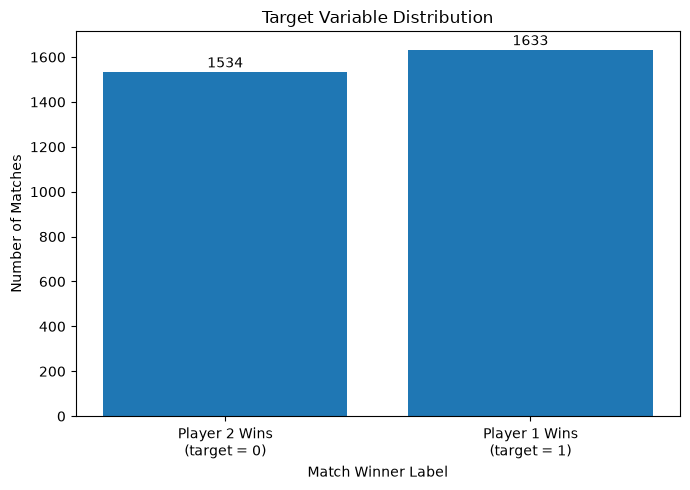

In [72]:
import matplotlib.pyplot as plt

target_counts = model_df["target"].value_counts().sort_index()

labels = ["Player 2 Wins\n(target = 0)", "Player 1 Wins\n(target = 1)"]

plt.figure(figsize=(7, 5))
plt.bar(labels, target_counts.values)

plt.title("Target Variable Distribution")
plt.xlabel("Match Winner Label")
plt.ylabel("Number of Matches")

for i, value in enumerate(target_counts.values):
    plt.text(i, value + 20, str(value), ha="center")

plt.tight_layout()
plt.savefig("../reports/figures/target_distribution.png", dpi=300)
plt.show()

In [73]:
print(model_df.columns.tolist())

['match_id', 'Player 1', 'Player 2', 'Pl 1 hand', 'Pl 2 hand', 'Date', 'Tournament', 'Round', 'Surface', 'Best of', 'Final TB?', 'Year', 'PtWinner', 'target', 'Winner']


In [74]:
model_df = matches_clean.merge(
    match_winners,
    on="match_id",
    how="inner"
)

model_df.shape

(3167, 13)

In [75]:
print(model_df.columns.tolist())

['match_id', 'Player 1', 'Player 2', 'Pl 1 hand', 'Pl 2 hand', 'Date', 'Tournament', 'Round', 'Surface', 'Best of', 'Final TB?', 'Year', 'PtWinner']


In [76]:
print(model_df["Tournament"].dropna().unique()[:100])

<StringArray>
[          'Roland Garros',            'Rome Masters',
          'Madrid Masters',               'Barcelona',
                  'Munich',     'Monte Carlo Masters',
               'Wuning CH',               'Bucharest',
           'Miami Masters',            'Sao Paulo CH',
    'Indian Wells Masters',             'Santiago CH',
                   'Dubai',                'Acapulco',
                    'Doha',          'Rio de Janeiro',
            'Delray Beach',               'Rotterdam',
            'Buenos Aires',                  'Dallas',
    'Davis Cup Qualifiers',             'Montpellier',
 'Australian Open Juniors',         'Australian Open',
               'Itajai CH',                'Adelaide',
              'United Cup',               'Hong Kong',
                'Brisbane',             'Canberra CH',
            'Bengaluru CH',          'NextGen Finals',
     'Dutch Championships',        'Davis Cup Finals',
  'NCAA Individual Finals',             'Tour Final

In [77]:
print(model_df["Tournament"].value_counts().head(30))

Tournament
Australian Open         233
US Open                 200
Roland Garros           180
Indian Wells Masters    168
Miami Masters           156
Wimbledon               136
Monte Carlo Masters     114
Madrid Masters          111
Rome Masters             98
Paris Masters            95
Rotterdam                91
Canada Masters           88
Cincinnati Masters       65
Tour Finals              58
Dubai                    51
Shanghai Masters         49
Barcelona                42
Halle                    42
Vienna                   41
United Cup               38
Davis Cup Finals         36
Doha                     34
Queens Club              32
Stuttgart                32
Brisbane                 31
Washington               30
Acapulco                 27
Basel                    27
Tokyo                    25
Beijing                  24
Name: count, dtype: int64


In [78]:
def classify_tournament_level(tournament_name):
    if pd.isna(tournament_name):
        return "Other"

    name = str(tournament_name).strip()

    grand_slams = {
        "Australian Open",
        "Roland Garros",
        "Wimbledon",
        "US Open",
    }

    atp_finals = {
        "Tour Finals",
    }

    masters_1000 = {
        "Indian Wells Masters",
        "Miami Masters",
        "Monte Carlo Masters",
        "Madrid Masters",
        "Rome Masters",
        "Canada Masters",
        "Cincinnati Masters",
        "Shanghai Masters",
        "Paris Masters",
    }

    atp_500 = {
        "Rotterdam",
        "Dubai",
        "Barcelona",
        "Halle",
        "Vienna",
        "Queens Club",
        "Basel",
        "Tokyo",
        "Beijing",
        "Acapulco",
        "Rio de Janeiro",
    }

    if name in grand_slams:
        return "Grand Slam"

    if name in atp_finals:
        return "ATP Finals"

    if name in masters_1000:
        return "Masters 1000"

    if name in atp_500:
        return "ATP 500"

    if name.endswith(" CH"):
        return "Challenger"

    return "ATP 250 / Other"

In [79]:
model_df["tournament_level"] = model_df["Tournament"].apply(
    classify_tournament_level
)

In [80]:
print(model_df["tournament_level"].value_counts())

tournament_level
Masters 1000       944
ATP 250 / Other    788
Grand Slam         772
ATP 500            421
Challenger         184
ATP Finals          58
Name: count, dtype: int64


In [81]:
print(
    model_df.loc[
        model_df["tournament_level"] == "ATP 250 / Other",
        "Tournament"
    ]
    .value_counts()
    .head(50)
)

Tournament
United Cup                 38
Davis Cup Finals           36
Doha                       34
Stuttgart                  32
Brisbane                   31
Washington                 30
Buenos Aires               23
Montpellier                23
Olympics                   23
Davis Cup Qualifiers       22
Gstaad                     21
Adelaide                   18
s Hertogenbosch            17
Hamburg                    17
Marseille                  17
Antwerp                    16
Astana                     16
Estoril                    14
Dallas                     13
Stockholm                  13
Newport                    13
ATP Cup                    13
Hong Kong                  12
NextGen Finals             12
Metz                       12
Eastbourne                 12
Munich                     11
Bastad                     11
Geneva                     11
Winston Salem               9
Houston                     9
Auckland                    9
Umag                        8

In [82]:
def classify_tournament_level(tournament_name):
    if pd.isna(tournament_name):
        return "Other"

    name = str(tournament_name).strip()

    grand_slams = {
        "Australian Open",
        "Roland Garros",
        "Wimbledon",
        "US Open",
    }

    atp_finals = {
        "Tour Finals",
    }

    masters_1000 = {
        "Indian Wells Masters",
        "Miami Masters",
        "Monte Carlo Masters",
        "Madrid Masters",
        "Rome Masters",
        "Canada Masters",
        "Cincinnati Masters",
        "Shanghai Masters",
        "Paris Masters",
    }

    atp_500 = {
        "Rotterdam",
        "Dubai",
        "Barcelona",
        "Halle",
        "Vienna",
        "Queens Club",
        "Basel",
        "Tokyo",
        "Beijing",
        "Acapulco",
        "Rio de Janeiro",
        "Washington",
        "Hamburg",
    }

    team_events = {
        "United Cup",
        "ATP Cup",
        "Davis Cup Finals",
        "Davis Cup Qualifiers",
        "Davis Cup World Group",
    }

    special_events = {
        "Olympics",
        "NextGen Finals",
        "Six Kings Slam",
    }

    if name in grand_slams:
        return "Grand Slam"

    if name in atp_finals:
        return "ATP Finals"

    if name in masters_1000:
        return "Masters 1000"

    if name in atp_500:
        return "ATP 500"

    if name in team_events:
        return "Team Event"

    if name in special_events:
        return "Special Event"

    if name.endswith(" CH"):
        return "Challenger"

    if "Junior" in name:
        return "Junior"

    if "NCAA" in name or "Championships" in name:
        return "College / National"

    return "ATP 250"

In [83]:
model_df["tournament_level"] = model_df["Tournament"].apply(
    classify_tournament_level
)

In [84]:
model_df["tournament_level"].value_counts()

tournament_level
Masters 1000          944
Grand Slam            772
ATP 250               575
ATP 500               468
Challenger            184
Team Event            114
ATP Finals             58
Special Event          38
Junior                  9
College / National      5
Name: count, dtype: int64

In [85]:
model_df.loc[
    model_df["tournament_level"] == "ATP 250",
    "Tournament"
].value_counts().head(50)

Tournament
Doha               34
Stuttgart          32
Brisbane           31
Buenos Aires       23
Montpellier        23
Gstaad             21
Adelaide           18
s Hertogenbosch    17
Marseille          17
Antwerp            16
Astana             16
Estoril            14
Dallas             13
Stockholm          13
Newport            13
Hong Kong          12
Metz               12
Eastbourne         12
Munich             11
Bastad             11
Geneva             11
Winston Salem       9
Houston             9
Auckland            9
Umag                8
Santiago            8
Athens              7
Marrakech           7
Los Cabos           7
Tel Aviv            7
Seoul               7
Delray Beach        6
Chengdu             6
Belgrade            6
Cordoba             6
Gijon               6
Melbourne           6
Bucharest           5
Almaty              5
Kitzbuhel           5
Lyon                5
Banja Luka          5
Pune                5
Tokyo Olympics      4
Brussels            3

In [86]:
model_df = model_df.sort_values("Date").reset_index(drop=True)

In [87]:
model_df_features = pd.concat(
    [model_df.reset_index(drop=True), historical_features],
    axis=1
)

In [88]:
features = [
    "Pl 1 hand",
    "Pl 2 hand",
    "Round",
    "Surface",
    "Best of",
    "Final TB?",
    "Year",
    "tournament_level",

    "p1_previous_matches",
    "p2_previous_matches",
    "experience_diff",

    "p1_previous_win_rate",
    "p2_previous_win_rate",
    "win_rate_diff",

    "p1_surface_matches",
    "p2_surface_matches",
    "surface_experience_diff",

    "p1_surface_win_rate",
    "p2_surface_win_rate",
    "surface_win_rate_diff"
]

model_data_stronger = model_df_features[
    features + ["target"]
].copy()

model_data_stronger.to_csv(
    "../data/processed/model_dataset_stronger_tournament_2021.csv",
    index=False
)

model_data_stronger.head()

KeyError: "['target'] not in index"